# Ablation Study: Text Preprocessing Parameters

This notebook systematically evaluates the impact of three preprocessing toggles — **normalisation** (`norm`), **numeric removal** (`num`), and **stop-word removal** (`stop`) — across both pipelines:

| Pipeline | Cleaner | Vectoriser | Classifier |
|----------|---------|------------|------------|
| BOW | `StemCleaner` | TF-IDF char n-grams | LinearSVC |
| Semantic | `LemmaCleaner` | Sentence-BERT embeddings | Random Forest |

Each pipeline is run under all 8 combinations of the three binary flags. We report **5-fold CV macro-F1** (on the training set) and **test-set macro-F1** for every configuration.

In [1]:
from datasets import load_dataset

import itertools
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

from Cleaners import StemCleaner, LemmaCleaner
warnings.filterwarnings('ignore')

In [2]:
raw = load_dataset("csv", data_files="cw_data.csv", column_names=["text", "label"])
dataset = raw["train"]
y = dataset["label"]

## 1 Cleaner Definitions

Identical to the classes in `BOW_Approach.ipynb` and `Semantic_Approach.ipynb`.

## 2 Ablation Runner

We iterate over every `(norm, num, stop)` combination for both pipelines, recording CV and test macro-F1.

In [3]:
FLAG_COMBOS = list(itertools.product([False, True], repeat=3))

sbert = SentenceTransformer('all-MiniLM-L6-v2')

results = []

for norm, num, stop in FLAG_COMBOS:
    tag = f"norm={norm}, num={num}, stop={stop}"
    print(f"Running: {tag}")

    # ── BOW pipeline ──
    parsed_bow = StemCleaner(dataset["text"], norm=norm, num=num, stop=stop)

    train_t, test_t, y_train, y_test = train_test_split(
        parsed_bow.rejoined, y, test_size=0.2, random_state=42, stratify=y
    )

    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
    X_train = vec.fit_transform(train_t)
    X_test  = vec.transform(test_t)

    bow_model = LinearSVC(class_weight='balanced', random_state=42)
    bow_model.fit(X_train, y_train)

    bow_cv = cross_val_score(bow_model, X_train, y_train, cv=5, scoring='f1_macro')
    bow_test_f1 = f1_score(y_test, bow_model.predict(X_test), average='macro')

    results.append({
        'pipeline': 'BOW (Stem + TF-IDF + SVC)',
        'norm': norm, 'num': num, 'stop': stop,
        'cv_f1_mean': bow_cv.mean(),
        'cv_f1_std':  bow_cv.std(),
        'test_f1':    bow_test_f1,
    })

    # ── Semantic pipeline ──
    parsed_sem = LemmaCleaner(dataset["text"], norm=norm, num=num, stop=stop)

    embeddings = sbert.encode(parsed_sem.rejoined)
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        embeddings, y, test_size=0.2, random_state=42, stratify=y
    )

    sem_model = RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    )
    sem_model.fit(X_train_s, y_train_s)

    sem_cv = cross_val_score(sem_model, X_train_s, y_train_s, cv=5, scoring='f1_macro')
    sem_test_f1 = f1_score(y_test_s, sem_model.predict(X_test_s), average='macro')

    results.append({
        'pipeline': 'Semantic (Lemma + SBERT + RF)',
        'norm': norm, 'num': num, 'stop': stop,
        'cv_f1_mean': sem_cv.mean(),
        'cv_f1_std':  sem_cv.std(),
        'test_f1':    sem_test_f1,
    })

df = pd.DataFrame(results)
print("\nDone — collected", len(df), "rows.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running: norm=False, num=False, stop=False
Running: norm=False, num=False, stop=True
Running: norm=False, num=True, stop=False
Running: norm=False, num=True, stop=True
Running: norm=True, num=False, stop=False
Running: norm=True, num=False, stop=True
Running: norm=True, num=True, stop=False
Running: norm=True, num=True, stop=True

Done — collected 16 rows.


## 3 Results Table

In [4]:
display_df = df.copy()
display_df['CV F1'] = display_df.apply(
    lambda r: f"{r['cv_f1_mean']:.3f} \u00b1 {r['cv_f1_std']:.3f}", axis=1
)
display_df['Test F1'] = display_df['test_f1'].map('{:.3f}'.format)

display_df[['pipeline', 'norm', 'num', 'stop', 'CV F1', 'Test F1']]

,pipeline,norm,num,stop,CV F1,Test F1
0,BOW (Stem + TF-IDF + SVC),False,False,False,0.901 ± 0.047,0.891
1,Semantic (Lemma + SBERT + RF),False,False,False,0.892 ± 0.038,0.939
2,BOW (Stem + TF-IDF + SVC),False,False,True,0.891 ± 0.043,0.885
3,Semantic (Lemma + SBERT + RF),False,False,True,0.885 ± 0.052,0.892
4,BOW (Stem + TF-IDF + SVC),False,True,False,0.901 ± 0.047,0.891
5,Semantic (Lemma + SBERT + RF),False,True,False,0.881 ± 0.057,0.904
6,BOW (Stem + TF-IDF + SVC),False,True,True,0.895 ± 0.043,0.885
7,Semantic (Lemma + SBERT + RF),False,True,True,0.913 ± 0.045,0.954
8,BOW (Stem + TF-IDF + SVC),True,False,False,0.896 ± 0.051,0.865
9,Semantic (Lemma + SBERT + RF),True,False,False,0.899 ± 0.033,0.907


## 4 Per-Parameter Effect (Marginal Analysis)

For each flag we compute the **average test macro-F1 when the flag is ON vs OFF**, marginalised over the other two flags. This isolates the individual contribution of each preprocessing step.

In [5]:
marginal_rows = []
for pipe in df['pipeline'].unique():
    sub = df[df['pipeline'] == pipe]
    for flag in ['norm', 'num', 'stop']:
        off = sub[sub[flag] == False]['test_f1'].mean()
        on  = sub[sub[flag] == True]['test_f1'].mean()
        marginal_rows.append({
            'pipeline': pipe, 'parameter': flag,
            'OFF': off, 'ON': on, 'delta': on - off
        })

marginal = pd.DataFrame(marginal_rows)
marginal['delta_fmt'] = marginal['delta'].map(lambda d: f"{d:+.3f}")
marginal[['pipeline', 'parameter', 'OFF', 'ON', 'delta_fmt']]

,pipeline,parameter,OFF,ON,delta_fmt
0,BOW (Stem + TF-IDF + SVC),norm,0.887792,0.873554,-0.014
1,BOW (Stem + TF-IDF + SVC),num,0.880673,0.880673,+0.000
2,BOW (Stem + TF-IDF + SVC),stop,0.877926,0.883420,+0.005
3,Semantic (Lemma + SBERT + RF),norm,0.922164,0.906868,-0.015
4,Semantic (Lemma + SBERT + RF),num,0.911373,0.917659,+0.006
5,Semantic (Lemma + SBERT + RF),stop,0.917508,0.911524,-0.006


## 5 Visualisation

### 5.1 Grouped Bar Chart — All 8 Configurations per Pipeline

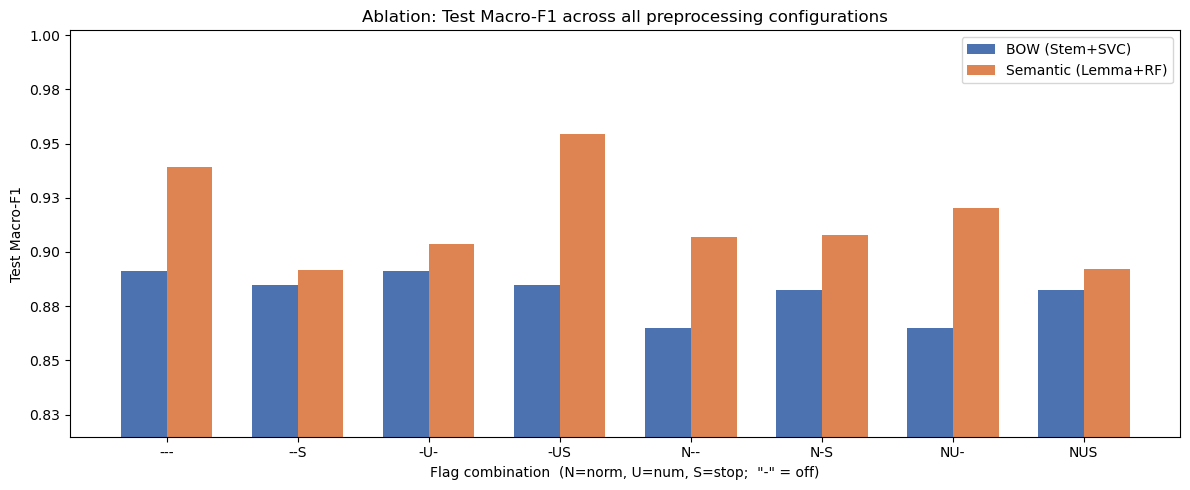

In [6]:
bow_df = df[df['pipeline'].str.startswith('BOW')].reset_index(drop=True)
sem_df = df[df['pipeline'].str.startswith('Semantic')].reset_index(drop=True)

labels = [
    f"{'N' if r.norm else '-'}{'U' if r.num else '-'}{'S' if r.stop else '-'}"
    for _, r in bow_df.iterrows()
]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(labels))
w = 0.35

ax.bar([i - w/2 for i in x], bow_df['test_f1'], w, label='BOW (Stem+SVC)', color='#4C72B0')
ax.bar([i + w/2 for i in x], sem_df['test_f1'], w, label='Semantic (Lemma+RF)', color='#DD8452')

ax.set_xlabel('Flag combination  (N=norm, U=num, S=stop;  "-" = off)')
ax.set_ylabel('Test Macro-F1')
ax.set_title('Ablation: Test Macro-F1 across all preprocessing configurations')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend()
ax.set_ylim(bottom=max(0, df['test_f1'].min() - 0.05))
plt.tight_layout()
plt.show()

### 5.2 Marginal Delta Plot — Per-Parameter Impact

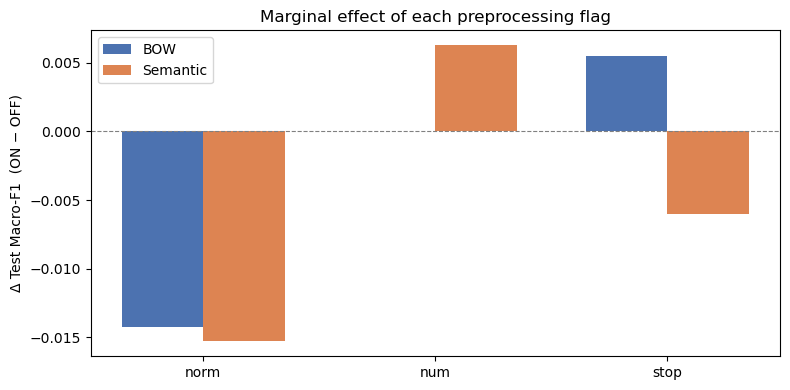

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

params = ['norm', 'num', 'stop']
x = range(len(params))
w = 0.35

bow_deltas = marginal[marginal['pipeline'].str.startswith('BOW')].set_index('parameter').loc[params, 'delta']
sem_deltas = marginal[marginal['pipeline'].str.startswith('Semantic')].set_index('parameter').loc[params, 'delta']

bars1 = ax.bar([i - w/2 for i in x], bow_deltas, w, label='BOW', color='#4C72B0')
bars2 = ax.bar([i + w/2 for i in x], sem_deltas, w, label='Semantic', color='#DD8452')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xticks(list(x))
ax.set_xticklabels(params)
ax.set_ylabel('\u0394 Test Macro-F1  (ON \u2212 OFF)')
ax.set_title('Marginal effect of each preprocessing flag')
ax.legend()
plt.tight_layout()
plt.show()

## 6 Best Configuration per Pipeline

In [8]:
for pipe in df['pipeline'].unique():
    sub = df[df['pipeline'] == pipe]
    best = sub.loc[sub['test_f1'].idxmax()]
    print(f"{pipe}")
    print(f"  Best config : norm={best['norm']}, num={best['num']}, stop={best['stop']}")
    print(f"  Test F1     : {best['test_f1']:.3f}")
    print(f"  CV F1       : {best['cv_f1_mean']:.3f} \u00b1 {best['cv_f1_std']:.3f}")
    print()

BOW (Stem + TF-IDF + SVC)
  Best config : norm=False, num=False, stop=False
  Test F1     : 0.891
  CV F1       : 0.901 ± 0.047

Semantic (Lemma + SBERT + RF)
  Best config : norm=False, num=True, stop=True
  Test F1     : 0.954
  CV F1       : 0.913 ± 0.045



## 7 Discussion

**`norm` (text normalisation)** — Maps informal tokens (`wat` -> `what`, `acct` -> `account`, `cant` -> `cannot`) to their standard forms. This is expected to help the BOW pipeline more than the semantic pipeline, because character n-gram TF-IDF cannot infer that `wat` and `what` share meaning, whereas Sentence-BERT embeddings can often capture informal synonyms from pre-training context.

**`num` (numeric removal)** — Strips standalone digits like `2`. Since the normalisation map already converts `2` -> `to` when `norm=True`, this flag's effect is mostly visible when `norm=False`. Removing numerics can reduce noise but may also discard meaningful tokens in contexts like \"2-factor\".

**`stop` (stop-word removal)** — Removes high-frequency function words while preserving negations (`not`, `no`, `cannot`). For the BOW pipeline this concentrates TF-IDF weight on content words. For the semantic pipeline, stop words carry syntactic context that Sentence-BERT was trained on, so removing them may hurt embedding quality.

### Key Takeaway

Refer to the delta plot above: bars above zero indicate the flag **helps** that pipeline; bars below zero indicate it **hurts**. The optimal flag combination differs between the two pipelines, confirming that preprocessing choices should be tuned per-model rather than applied universally.